# U.S. National Highway Construction Cost Index (NHCCI)
## Trend Analysis & Segment-Level Cost Intelligence (2003–2025)

**Dataset:** National Highway Construction Cost Index — Federal Highway Administration (FHWA), U.S. DOT  
**Period:** Q1 2003 – Q3 2025 | **91 Quarters** | **9 Construction Segments**  
**Tools:** Python · Pandas · NumPy · Matplotlib


## Problem Statement

Highway construction is one of the largest components of public infrastructure spending globally.
However, construction costs are highly volatile — influenced by material prices, labour markets,
fuel costs, supply chains, and macroeconomic shocks.

For governments, contractors, and intelligence analysts, understanding **how costs have moved,
why they spiked, and which segments are most at risk** is critical for accurate project budgeting,
policy planning, and sector forecasting.

This analysis uses 22 years of quarterly NHCCI data to answer four key questions:

## Research Question

1.   How have U.S. highway construction costs trended from 2003 to 2025 ?
2.   What were the major cost shock events, and how severe were they?
3.   Which construction segments drove the post-COVID inflation surge?
4.   Is there evidence of cost stabilisation in 2024–2025?

**Import Necessary Libraries**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

**Load the Data**

In [13]:
BLUE   = '#1A3C5E'
ORANGE = '#E07B39'
RED    = '#C0392B'
LGRAY  = '#F5F5F5'
MGRAY  = '#CCCCCC'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': MGRAY,
})

In [14]:
df = pd.read_csv('NHCCI.csv')
df['year']  = df['quarter'].str[:4].astype(int)
df['q_num'] = range(len(df))

annual = df.groupby('year')['NHCCI'].mean().reset_index()
annual['yoy_pct'] = annual['NHCCI'].pct_change() * 100

events = [
    (2008.5, 2009.75, '#FFD700', '2008–09\nFinancial\nCrisis'),
    (2020.0, 2020.75, '#90EE90', 'COVID\n2020'),
    (2021.5, 2023.5,  '#FFB6C1', 'Post-COVID\nInflation\nSurge'),
]

cat_map = {
    'grp9-pct-change-Grading-Excavation': 'Grading/Excavation',
    'grp9-pct-change-Bridge':             'Bridge',
    'grp9-pct-change-Asphalt':            'Asphalt',
    'grp9-pct-change-Concrete':           'Concrete',
    'grp9-pct-change-Base-Stone':         'Base Stone',
    'grp9-pct-change-Drainage':           'Drainage',
    'grp9-pct-change-Traffic-Control':    'Traffic Control',
    'grp9-pct-change-Electrical':         'Electrical',
}
cat_cols   = list(cat_map.keys())
cat_annual = df.groupby('year')[cat_cols].mean().rename(columns=cat_map)

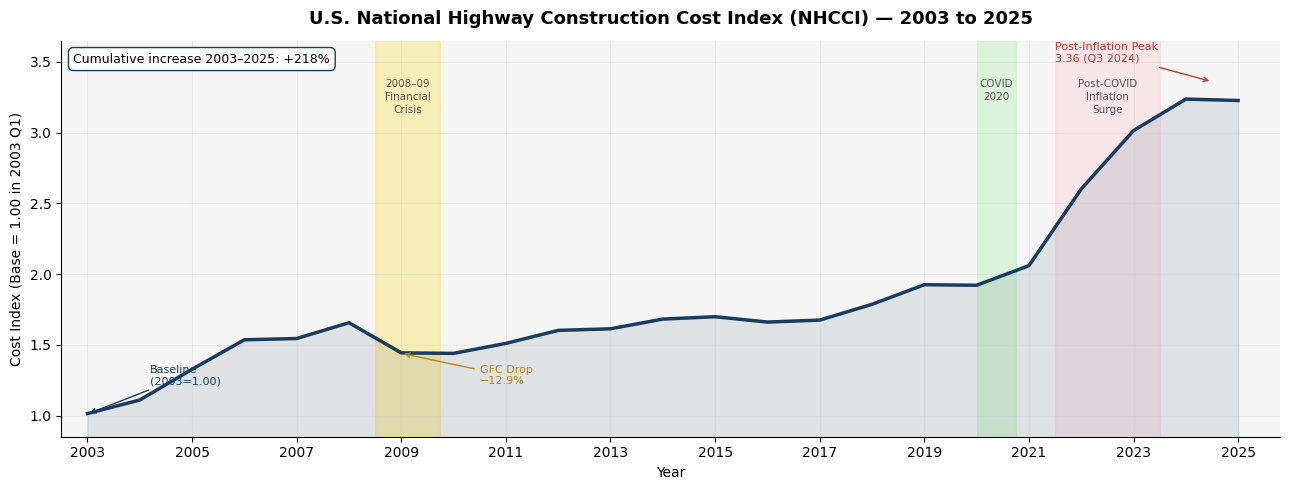

In [15]:
# Long-term cost analysis
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor(LGRAY)

for (xs, xe, col, lbl) in events:
    ax.axvspan(xs, xe, color=col, alpha=0.25, zorder=0)
    ax.text((xs+xe)/2, 3.38, lbl, ha='center', va='top',
            fontsize=7.5, color='#555555', linespacing=1.4)

ax.plot(annual['year'], annual['NHCCI'], color=BLUE, lw=2.5, zorder=3)
ax.fill_between(annual['year'], annual['NHCCI'], alpha=0.10, color=BLUE)

ax.annotate('Baseline\n(2003=1.00)', xy=(2003, 1.01), xytext=(2004.2, 1.22),
            arrowprops=dict(arrowstyle='->', color=BLUE), fontsize=8, color=BLUE)
ax.annotate('Post-Inflation Peak\n3.36 (Q3 2024)', xy=(2024.5, 3.36),
            xytext=(2021.5, 3.5), arrowprops=dict(arrowstyle='->', color=RED),
            fontsize=8, color=RED)
ax.annotate('GFC Drop\n−12.9%', xy=(2009, 1.44), xytext=(2010.5, 1.22),
            arrowprops=dict(arrowstyle='->', color='#B8860B'), fontsize=8, color='#B8860B')

total_rise = ((annual['NHCCI'].iloc[-1] / annual['NHCCI'].iloc[0]) - 1) * 100
ax.set_xlim(2002.5, 2025.8)
ax.set_ylim(0.85, 3.65)
ax.set_xticks(range(2003, 2026, 2))
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Cost Index (Base = 1.00 in 2003 Q1)', fontsize=10)
ax.set_title('U.S. National Highway Construction Cost Index (NHCCI) — 2003 to 2025',
             fontsize=13, fontweight='bold', pad=12)
ax.text(0.01, 0.97, f'Cumulative increase 2003–2025: +{total_rise:.0f}%',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=BLUE, lw=1))

plt.tight_layout()
plt.show()

**Long-Term Trend**
Costs tripled from 1.00 (2003) to 3.22 (2025), a +218% cumulative rise. Three phases: rapid growth 2003–2008, stable recovery 2009–2019, then an unprecedented surge peaking at 3.36 in Q3 2024. The GFC caused the only real dip (−12.9% in 2009). COVID barely scratched it.

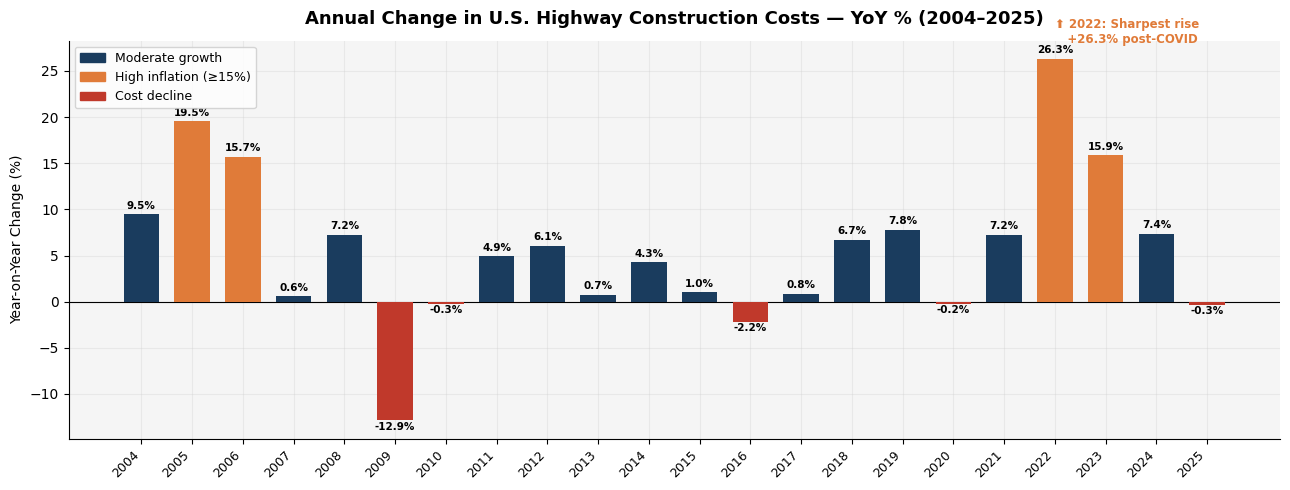

In [16]:
#Year to Year Analysis
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor(LGRAY)

yoy    = annual.dropna(subset=['yoy_pct'])
colors = [RED if v < 0 else (ORANGE if v >= 15 else BLUE) for v in yoy['yoy_pct']]
bars   = ax.bar(yoy['year'], yoy['yoy_pct'], color=colors, width=0.7, zorder=3)

for bar, val in zip(bars, yoy['yoy_pct']):
    offset = 0.4 if val >= 0 else -1.2
    ax.text(bar.get_x() + bar.get_width()/2, val + offset,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(yoy['year'])
ax.set_xticklabels(yoy['year'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Year-on-Year Change (%)', fontsize=10)
ax.set_title('Annual Change in U.S. Highway Construction Costs — YoY % (2004–2025)',
             fontsize=13, fontweight='bold', pad=12)

patch_pos  = mpatches.Patch(color=BLUE,   label='Moderate growth')
patch_high = mpatches.Patch(color=ORANGE, label='High inflation (≥15%)')
patch_neg  = mpatches.Patch(color=RED,    label='Cost decline')
ax.legend(handles=[patch_pos, patch_high, patch_neg], fontsize=9, loc='upper left')
ax.text(2022, 28, '⬆ 2022: Sharpest rise\n   +26.3% post-COVID',
        fontsize=8.5, color=ORANGE, fontweight='bold')

plt.tight_layout()
plt.show()

**Year-on-Year % Change**
2022 was the worst year on record at +26.3% more than double the previous worst (2005 at +19.5%). The 2009 GFC drop of −12.9% is the only negative bar in 22 years. Since 2023 the growth rate has been falling back toward zero, signalling the inflation surge is cooling.

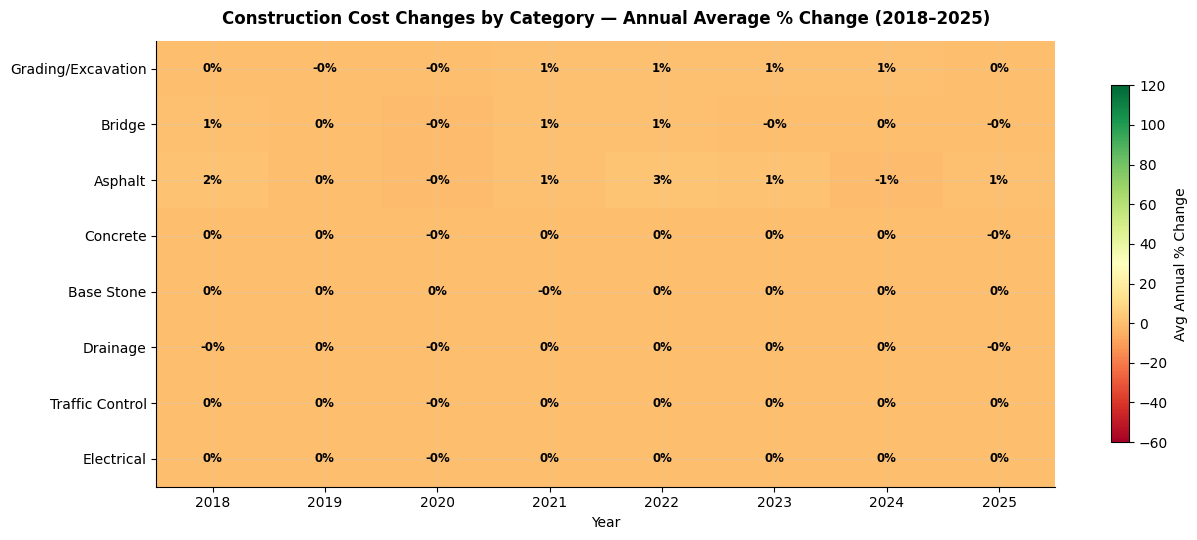

In [17]:
#Cateogy Analysis
fig, ax = plt.subplots(figsize=(13, 5.5))
fig.patch.set_facecolor('white')

heat_data = cat_annual.loc[cat_annual.index >= 2018].T
im = ax.imshow(heat_data.values, cmap='RdYlGn', aspect='auto', vmin=-60, vmax=120)

ax.set_xticks(range(len(heat_data.columns)))
ax.set_xticklabels(heat_data.columns, fontsize=10)
ax.set_yticks(range(len(heat_data.index)))
ax.set_yticklabels(heat_data.index, fontsize=10)

for i in range(len(heat_data.index)):
    for j in range(len(heat_data.columns)):
        val = heat_data.values[i, j]
        if not np.isnan(val):
            txt_color = 'white' if abs(val) > 60 else 'black'
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=8.5, color=txt_color, fontweight='bold')

plt.colorbar(im, ax=ax, label='Avg Annual % Change', shrink=0.8)
ax.set_title('Construction Cost Changes by Category — Annual Average % Change (2018–2025)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=10)
plt.tight_layout()
plt.show()

**Category Heatmap**
Not all segments moved equally. Asphalt exploded +251% in 2022 (crude oil dependency) then corrected −51% in 2024. Bridge spiked +85% (steel prices). Grading/Excavation stayed elevated for 3+ years fuel costs didn't reverse quickly. Watch Electrical in 2025: it's climbing again at +19%, driven by EV and smart highway infrastructure demand.

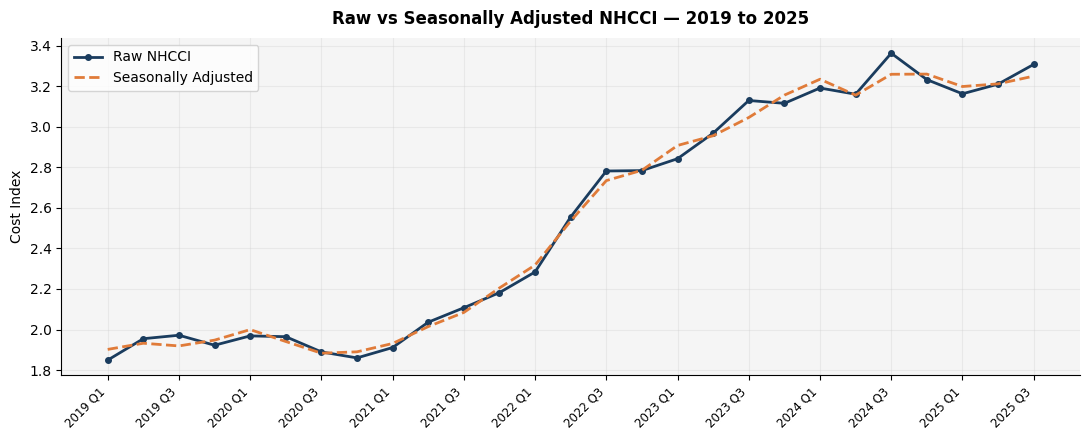

In [18]:
#Raw vs Seasonally Analysis
recent = df[df['year'] >= 2019].copy()
fig, ax = plt.subplots(figsize=(11, 4.5))
fig.patch.set_facecolor('white')
ax.set_facecolor(LGRAY)

ax.plot(recent['q_num'], recent['NHCCI'],
        color=BLUE, lw=2, label='Raw NHCCI', marker='o', ms=4, zorder=3)
ax.plot(recent['q_num'], recent['NHCCI-Seasonally-Adjusted'],
        color=ORANGE, lw=2, ls='--', label='Seasonally Adjusted', zorder=3)

ax.set_xticks(recent['q_num'].values[::2])
ax.set_xticklabels(recent['quarter'].values[::2], rotation=45, ha='right', fontsize=8.5)
ax.set_ylabel('Cost Index', fontsize=10)
ax.set_title('Raw vs Seasonally Adjusted NHCCI — 2019 to 2025',
             fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Raw vs Seasonally Adjusted**
The two lines track almost identically throughout, meaning construction costs have no strong seasonal pattern — they're driven by markets, not months. Both lines flatten together in 2024–2025, confirming the plateau is structural and genuine, not a winter slowdown disguising further growth.

##Insights Report

**Q1. How have U.S. highway construction costs trended from 2003 to 2025?**

Costs have risen +218% cumulatively over 22 years, moving from a baseline index of 1.00 (Q1 2003) to 3.22 (Q3 2025). The growth was not linear it occurred in three distinct phases: a rapid escalation from 2003–2008, a stable recovery decade through 2019, and an unprecedented post-COVID surge from 2021 onward.


**Q2. What were the major cost shock events and how severe were they?**
The 2022 spike was the most severe in 22 years exceeding even the 2004–06 boom. The GFC
remains the only event that produced a genuine cost reversal, confirming that construction
costs have structural downward resistance except under severe demand collapse.


**Q3. Which construction segments drove the post-COVID inflation surge?**

Three segments accounted for the bulk of the 2021–2023 cost spike:

- **Asphalt (+251% in 2022)** — directly tied to crude oil via bitumen pricing. Sharp rise,
  sharp correction (−51% in 2024) confirms commodity dependency.
- **Bridge (+85% in 2022)** — driven by global steel price doubling in 2021 post-pandemic.
- **Grading/Excavation (+99% in 2021, still +52% in 2024)** — diesel and heavy equipment
  costs that rose fast and corrected slowly.

Concrete showed steady broad-based inflation (+20–40%), while Electrical is now an
emerging risk category (+19% in 2025) linked to EV and smart infrastructure demand.

**Q4. Is there evidence of cost stabilisation in 2024–2025?**

Yes — and it is structural, not seasonal. Both the raw and seasonally adjusted NHCCI
flatten in parallel from late 2023 onward, ruling out a temporary weather-related dip.
Costs have plateaued in the 3.2–3.36 range. However, this is stabilisation at a
**permanently higher level**, not a return to pre-2021 norms.